# Finite allocation

An optimiser returns *continuous* weights — fractions of capital. To actually trade them you need
whole shares at real prices under a finite cash budget, and the rounding is not free: it pulls the
realised portfolio away from the target, and the smaller the account the more it hurts.
`PortfolioOptimisers.jl` provides two finite-allocation optimisers — a fast solver-free heuristic
and an exact mixed-integer one — both called through the same `optimise(allocator, w, prices, cash)`
interface.

  - `GreedyAllocation` — a two-pass heuristic: round to whole (or lot-sized) shares, then
    spend the leftover cash on the largest underweights. No solver needed.
  - `DiscreteAllocation` — solves a mixed-integer program for the *optimal* whole-share
    book. Needs a MIP solver.

> **When to reach for this**
>
> Reach for finite allocation as the last step before trading, always — continuous weights are
> not executable. Use `GreedyAllocation` when you want an instant, dependable answer
> (and for very large books where the MIP is slow); use `DiscreteAllocation` when the
> account is small enough that the rounding genuinely matters and you want the provably best
> integer book. Watch the realised-vs-target drift — it is your discretisation error.

In [1]:
using PortfolioOptimisers, CSV, TimeSeries, DataFrames, PrettyTables, Clarabel, HiGHS,
      StatsPlots, GraphRecipes

resfmt = (v, i, j) -> begin
    return if j == 1
        v
    else
        isa(v, AbstractFloat) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. A target portfolio and prices

We optimise a minimum-risk book, then read the latest prices off the price series — finite
allocation needs both the target weights and a price per share.

In [2]:
X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)
pr = prior(EmpiricalPrior(), rd)

slv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))

res = optimise(MeanRisk(; obj = MinimumRisk(), opt = JuMPOptimiser(; pe = pr, slv = slv)))
prices = vec(values(X)[end, :])

20-element Vector{Float64}:
 125.674
  62.57
  32.301
  78.279
 173.728
  63.883
 311.22
 174.085
 129.575
  62.609
 363.098
 109.581
 233.434
 179.278
  49.25
 149.133
  24.497
 524.422
 140.181
 106.627

## 2. Greedy allocation

`GreedyAllocation` needs no solver. The result carries the integer `shares`, the per-asset
`cost`, the *realised* weights `w`, and the leftover `cash`. With a \$100,000 budget the realised
weights track the target tightly and only a few dollars go uninvested.

In [3]:
cash = 100_000.0
greedy = optimise(GreedyAllocation(), res.w, prices, cash)

drift(alloc) = sum(abs, alloc.w .- res.w)
pretty_table(DataFrame("Asset" => rd.nx, "Target" => res.w,
                       "Shares" => round.(Int, greedy.shares), "Realised" => greedy.w);
             formatters = [resfmt],
             title = "Greedy allocation of \$$(round(Int, cash)) — leftover cash \$$(round(greedy.cash, digits = 2)), drift $(round(drift(greedy), digits = 4))")

Greedy allocation of $100000 — leftover cash $14.22, drift 0.0033
┌────────┬──────────┬────────┬──────────┐
│  Asset │   Target │ Shares │ Realised │
│ String │  Float64 │  Int64 │  Float64 │
├────────┼──────────┼────────┼──────────┤
│   AAPL │    0.0 % │      0 │    0.0 % │
│    AMD │    0.0 % │      0 │    0.0 % │
│    BAC │    0.0 % │      0 │    0.0 % │
│    BBY │    0.0 % │      0 │    0.0 % │
│    CVX │  7.432 % │     43 │  7.471 % │
│     GE │  0.806 % │     13 │  0.831 % │
│     HD │    0.0 % │      0 │    0.0 % │
│    JNJ │ 36.974 % │    212 │ 36.911 % │
│    JPM │  0.749 % │      6 │  0.778 % │
│     KO │ 11.161 % │    178 │ 11.146 % │
│    LLY │    0.0 % │      0 │    0.0 % │
│    MRK │ 17.467 % │    159 │ 17.426 % │
│   MSFT │    0.0 % │      0 │    0.0 % │
│    PEP │  8.978 % │     50 │  8.965 % │
│      ⋮ │        ⋮ │      ⋮ │        ⋮ │
└────────┴──────────┴────────┴──────────┘
                           6 rows omitted


## 3. Exact allocation with a MIP solver

`DiscreteAllocation` solves for the *optimal* whole-share book instead of a greedy one.
It needs a mixed-integer solver — here [HiGHS](https://github.com/jump-dev/HiGHS.jl). On a book
this size the greedy heuristic is already at (or very near) the optimum, so the two agree; the
value of the MIP shows up on tighter budgets and lot constraints where the greedy pass can leave
gains on the table.

In [4]:
mip_slv = Solver(; name = :highs, solver = HiGHS.Optimizer,
                 settings = Dict("log_to_console" => false))
discrete = optimise(DiscreteAllocation(; slv = mip_slv), res.w, prices, cash)

pretty_table(DataFrame("Method" => ["Greedy", "Discrete (MIP)"],
                       "Leftover cash" => [greedy.cash, discrete.cash],
                       "Drift from target" => [drift(greedy), drift(discrete)]);
             formatters = [resfmt], title = "Greedy vs exact allocation")

              Greedy vs exact allocation
┌────────────────┬───────────────┬───────────────────┐
│         Method │ Leftover cash │ Drift from target │
│         String │       Float64 │           Float64 │
├────────────────┼───────────────┼───────────────────┤
│         Greedy │      1422.3 % │            0.33 % │
│ Discrete (MIP) │      1422.3 % │            0.33 % │
└────────────────┴───────────────┴───────────────────┘


## 4. Lot sizes

Many instruments trade in lots, not single shares. `GreedyAllocation(; unit = u)` rounds to
multiples of `u` shares. Coarser lots mean a coarser allocation — the drift grows, and a large lot
can even overshoot the budget (the leftover cash goes negative), which is the signal that the lot
size is too big for the account.

In [5]:
greedy_lots = optimise(GreedyAllocation(; unit = 10), res.w, prices, cash)

pretty_table(DataFrame("Allocation" => ["Single shares", "Lots of 10"],
                       "Leftover cash" => [greedy.cash, greedy_lots.cash],
                       "Drift from target" => [drift(greedy), drift(greedy_lots)]);
             formatters = [resfmt], title = "Lot size coarsens the allocation")

          Lot size coarsens the allocation
┌───────────────┬───────────────┬───────────────────┐
│    Allocation │ Leftover cash │ Drift from target │
│        String │       Float64 │           Float64 │
├───────────────┼───────────────┼───────────────────┤
│ Single shares │      1422.3 % │            0.33 % │
│    Lots of 10 │    -26844.0 % │           3.388 % │
└───────────────┴───────────────┴───────────────────┘


## 5. Budget size is the discretisation error

The same rounding that is negligible on a large account dominates a small one. Allocating the
identical target into \$100,000 versus \$5,000 shows the drift growing by an order of magnitude —
on a small account, the *choice* of finite-allocation method (and lot size) matters most.

In [6]:
budgets = [100_000.0, 25_000.0, 5_000.0]
budget_allocs = [optimise(GreedyAllocation(), res.w, prices, c) for c in budgets]

pretty_table(DataFrame("Budget" => budgets,
                       "Leftover cash" => [a.cash for a in budget_allocs],
                       "Drift from target" => [drift(a) for a in budget_allocs]);
             formatters = [resfmt],
             title = "Smaller budgets suffer larger discretisation error")

Smaller budgets suffer larger discretisation error
┌──────────┬───────────────┬───────────────────┐
│   Budget │ Leftover cash │ Drift from target │
│  Float64 │       Float64 │           Float64 │
├──────────┼───────────────┼───────────────────┤
│ 100000.0 │      1422.3 % │            0.33 % │
│  25000.0 │       519.1 % │           1.744 % │
│   5000.0 │       536.7 % │           9.469 % │
└──────────┴───────────────┴───────────────────┘


Both allocators also accept a `Fees` argument, so the share counts can be chosen net of
transaction costs (see [Fees and Net Returns](../4_constraints_costs/06_Fees_and_Net_Returns.md)).

## 6. Target vs realised

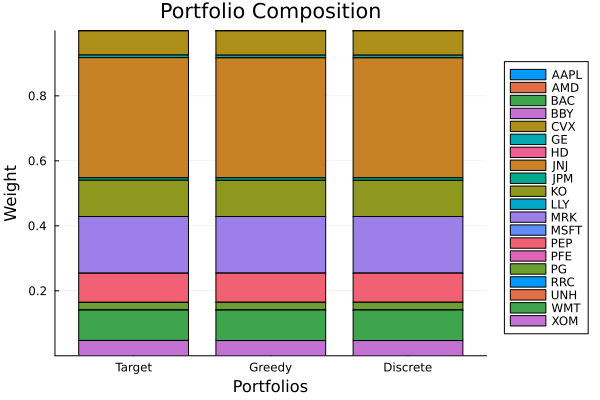

In [7]:
plot_stacked_bar_composition([res, greedy, discrete], rd;
                             xticks = (1:3, ["Target", "Greedy", "Discrete"]))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*